# Лабораторная работа 1 (вариант на 4): семантическая сегментация OpenSprayerSeg
Перед началом установите KAGGLE_USERNAME и KAGGLE_KEY в 3 ячейке

In [ ]:
!pip -q install kaggle albumentations opencv-python-headless segmentation-models-pytorch timm scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.1 MB/s eta 0:00:00


In [ ]:
import os
import gc
import json
import math
import random
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.cluster import MiniBatchKMeans

import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = False

@dataclass
class CFG:
    dataset_slug: str = "thatawkwardguy/opensprayerseg"
    project_dir: str = "/content/opensprayerseg_lab"
    image_size: int = 256
    batch_size: int = 16
    num_workers: int = 0
    seed: int = 42
    threshold: float = 0.5

    baseline_epochs: int = 4
    hypothesis_epochs: int = 2
    improved_epochs: int = 5
    custom_epochs: int = 4
    custom_improved_epochs: int = 5

    baseline_lr: float = 3e-4
    improved_lr: float = 2e-4
    custom_lr: float = 3e-4
    weight_decay: float = 1e-4
    early_stopping_patience: int = 2

    amp: bool = True
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

cfg = CFG()
PROJECT_DIR = Path(cfg.project_dir)
DATA_DIR = PROJECT_DIR / "data"
CKPT_DIR = PROJECT_DIR / "checkpoints"
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(cfg)
print("device:", cfg.device)

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(cfg.seed)

CFG(dataset_slug='thatawkwardguy/opensprayerseg', project_dir='/content/opensprayerseg_lab', image_size=256, batch_size=16, num_workers=0, seed=42, threshold=0.5, baseline_epochs=4, hypothesis_epochs=2, improved_epochs=5, custom_epochs=4, custom_improved_epochs=5, baseline_lr=0.0003, improved_lr=0.0002, custom_lr=0.0003, weight_decay=0.0001, early_stopping_patience=2, amp=True, device='cuda')
device: cuda


## Выбор начальных условий

Используется датасет **OpenSprayerSeg**. Необходимо выделять пиксели сорняков на изображениях поля. Практическая значимость состоит в том, что такая сегментация может использоваться в системах **точечного опрыскивания**, где гербицид вносится только по зонам сорняков, а не по всему полю. Это снижает расход химикатов и уменьшает воздействие на культурные растения.

Для сегментации выбраны:
1) Dice coefficient — основная метрика, хорошо показывает качество совпадения маски предсказания и истинной маски;
2) IoU (Jaccard) — классическая метрика сегментации, более строгая, чем Dice;
3) Precision — показывает, насколько мало ложных срабатываний по сорнякам;
4) Recall — показывает, насколько полно модель находит пиксели сорняков;
5) Pixel Accuracy — доля правильно классифицированных пикселей.

Основной метрикой сравнения во всех экспериментах будет Dice. Для бинарной сегментации сорняков эта метрика удобна, потому что напрямую измеряет качество перекрытия целевой области.

In [ ]:
KAGGLE_USERNAME = 
KAGGLE_KEY = 

if not KAGGLE_USERNAME or not KAGGLE_KEY:
    raise ValueError("Заполни KAGGLE_USERNAME и KAGGLE_KEY перед запуском этой ячейки.")

os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
os.environ["KAGGLE_KEY"] = KAGGLE_KEY

zip_path = DATA_DIR / "opensprayerseg.zip"
extract_dir = DATA_DIR

import subprocess

if not zip_path.exists():
    cmd = [
        "kaggle", "datasets", "download",
        "-d", cfg.dataset_slug,
        "-p", str(DATA_DIR),
    ]
    subprocess.run(cmd, check=True)

if not any(extract_dir.iterdir()):
    raise RuntimeError("Каталог data пуст после скачивания. Проверь Kaggle credentials.")

def dataset_already_extracted(root: Path) -> bool:
    names = {p.name for p in root.iterdir()}
    if {"train", "train_labels", "val", "val_labels", "test", "test_labels"}.issubset(names):
        return True
    for p in root.iterdir():
        if p.is_dir():
            sub = {q.name for q in p.iterdir()}
            if {"train", "train_labels", "val", "val_labels", "test", "test_labels"}.issubset(sub):
                return True
    return False

if not dataset_already_extracted(extract_dir):
    import zipfile
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("dataset_root =", extract_dir)

dataset_root = /content/opensprayerseg_lab/data


In [ ]:
EXPECTED_DIRS = ["train", "train_labels", "val", "val_labels", "test", "test_labels"]

def resolve_dataset_root(root: Path) -> Path:
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]
    for c in candidates:
        names = {p.name for p in c.iterdir()}
        if set(EXPECTED_DIRS).issubset(names):
            return c
    raise FileNotFoundError("Не удалось найти корень OpenSprayerSeg с train/val/test.")

DATASET_DIR = resolve_dataset_root(DATA_DIR)
print("DATASET_DIR =", DATASET_DIR)

for name in EXPECTED_DIRS:
    path = DATASET_DIR / name
    print(f"{name:12s} ->", len([p for p in path.iterdir() if p.is_file()]))

print("class_dict.csv exists:", (DATASET_DIR / "class_dict.csv").exists())

DATASET_DIR = /content/opensprayerseg_lab/data/OpenSprayerSeg
train        -> 4132
train_labels -> 4132
val          -> 39
val_labels   -> 39
test         -> 10
test_labels  -> 10
class_dict.csv exists: True


In [ ]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def build_split_df(images_dir: Path, masks_dir: Path, split_name: str) -> pd.DataFrame:
    image_files = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS])
    mask_files = sorted([p for p in masks_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS])

    image_map = {p.name: p for p in image_files}
    mask_map = {p.name: p for p in mask_files}
    common_names = sorted(set(image_map.keys()) & set(mask_map.keys()))

    if not common_names:
        image_map = {p.stem: p for p in image_files}
        mask_map = {p.stem: p for p in mask_files}
        common_names = sorted(set(image_map.keys()) & set(mask_map.keys()))

        rows = [{"image_path": str(image_map[name]), "mask_path": str(mask_map[name]), "filename": Path(image_map[name]).name, "split": split_name}
                for name in common_names]
    else:
        rows = [{"image_path": str(image_map[name]), "mask_path": str(mask_map[name]), "filename": name, "split": split_name}
                for name in common_names]

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(f"Для split={split_name} не найдено совпадающих пар image-mask.")
    return df

train_df = build_split_df(DATASET_DIR / "train", DATASET_DIR / "train_labels", "train")
val_df   = build_split_df(DATASET_DIR / "val", DATASET_DIR / "val_labels", "val")
test_df  = build_split_df(DATASET_DIR / "test", DATASET_DIR / "test_labels", "test")

print(train_df.shape, val_df.shape, test_df.shape)
display(train_df.head(3))
display(val_df.head(3))
display(test_df.head(3))

(4132, 4) (39, 4) (10, 4)


,image_path,mask_path,filename,split
0,/content/opensprayerseg_lab/data/OpenSprayerSe...,/content/opensprayerseg_lab/data/OpenSprayerSe...,10001_31869_21227.jpg,train
1,/content/opensprayerseg_lab/data/OpenSprayerSe...,/content/opensprayerseg_lab/data/OpenSprayerSe...,10001_31869_21227_aug_hflip.png,train
2,/content/opensprayerseg_lab/data/OpenSprayerSe...,/content/opensprayerseg_lab/data/OpenSprayerSe...,10001_31869_21227_aug_rotation.png,train


,image_path,mask_path,filename,split
0,/content/opensprayerseg_lab/data/OpenSprayerSe...,/content/opensprayerseg_lab/data/OpenSprayerSe...,10337_27587_2877.jpg,val
1,/content/opensprayerseg_lab/data/OpenSprayerSe...,/content/opensprayerseg_lab/data/OpenSprayerSe...,10624_18001_9875_aug_hflip.png,val
2,/content/opensprayerseg_lab/data/OpenSprayerSe...,/content/opensprayerseg_lab/data/OpenSprayerSe...,10861_26793_5777_aug_rotation.png,val


,image_path,mask_path,filename,split
0,/content/opensprayerseg_lab/data/OpenSprayerSe...,/content/opensprayerseg_lab/data/OpenSprayerSe...,10861_26793_5777_aug_rotation.png,test
1,/content/opensprayerseg_lab/data/OpenSprayerSe...,/content/opensprayerseg_lab/data/OpenSprayerSe...,14415_28968_17698_aug_hflip.png,test
2,/content/opensprayerseg_lab/data/OpenSprayerSe...,/content/opensprayerseg_lab/data/OpenSprayerSe...,15368_2681_27015_aug_rotation.png,test


In [ ]:
CLASS_DICT_PATH = DATASET_DIR / "class_dict.csv"

def parse_class_dict(csv_path: Path):
    if not csv_path.exists():
        return None, None, None, None

    df = pd.read_csv(csv_path)
    lower_map = {c.lower(): c for c in df.columns}

    name_col = None
    for candidate in ["name", "class", "class_name", "label", "class_names"]:
        if candidate in lower_map:
            name_col = lower_map[candidate]
            break
    if name_col is None:
        obj_cols = [c for c in df.columns if df[c].dtype == "object"]
        name_col = obj_cols[0] if obj_cols else df.columns[0]

    def find_color_col(letter: str):
        for c in df.columns:
            lc = c.lower()
            if lc == letter or lc.endswith(f"_{letter}") or lc.startswith(f"{letter}_"):
                return c
        for c in df.columns:
            if letter in c.lower():
                return c
        return None

    r_col, g_col, b_col = find_color_col("r"), find_color_col("g"), find_color_col("b")

    if not all([r_col, g_col, b_col]):
        if len(df.columns) >= 4:
            r_col, g_col, b_col = df.columns[1], df.columns[2], df.columns[3]
        else:
            raise ValueError("Не удалось определить RGB-столбцы в class_dict.csv.")

    classes = []
    for _, row in df.iterrows():
        classes.append({
            "name_raw": str(row[name_col]).strip(),
            "name": str(row[name_col]).strip().lower(),
            "color": np.array([row[r_col], row[g_col], row[b_col]], dtype=np.float32)
        })

    weed_idx = None
    not_weed_idx = None

    def is_positive_weed(name: str) -> bool:
        name = name.lower().strip()
        negative_tokens = ["not weed", "non weed", "no weed", "without weed", "background", "bg", "crop"]
        if any(tok in name for tok in negative_tokens):
            return False
        return "weed" in name or "weeds" in name or "sorn" in name

    def is_negative_weed(name: str) -> bool:
        name = name.lower().strip()
        return any(tok in name for tok in ["not weed", "non weed", "no weed", "background", "bg", "crop"])

    for idx, cls in enumerate(classes):
        if is_positive_weed(cls["name"]):
            weed_idx = idx
        if is_negative_weed(cls["name"]):
            not_weed_idx = idx

    if weed_idx is None and len(classes) == 2:
        name0 = classes[0]["name"]
        name1 = classes[1]["name"]
        if "not" in name0 and "weed" in name0:
            weed_idx = 1
            not_weed_idx = 0
        elif "not" in name1 and "weed" in name1:
            weed_idx = 0
            not_weed_idx = 1

    return df, classes, weed_idx, not_weed_idx

class_dict_df, CLASS_INFO, WEED_CLASS_INDEX_DECLARED, NOT_WEED_CLASS_INDEX_DECLARED = parse_class_dict(CLASS_DICT_PATH)

if class_dict_df is not None:
    display(class_dict_df)
    print("WEED_CLASS_INDEX_DECLARED =", WEED_CLASS_INDEX_DECLARED)
    print("NOT_WEED_CLASS_INDEX_DECLARED =", NOT_WEED_CLASS_INDEX_DECLARED)
    if WEED_CLASS_INDEX_DECLARED is not None:
        print("DECLARED WEED CLASS =", CLASS_INFO[WEED_CLASS_INDEX_DECLARED]["name_raw"])
        print("DECLARED WEED COLOR =", CLASS_INFO[WEED_CLASS_INDEX_DECLARED]["color"].astype(int).tolist())
else:
    print("class_dict.csv отсутствует, будет использоваться только анализ реальных цветов масок.")

,name,r,g,b
0,Not Weed,0,0,0
1,Weed,255,0,0


WEED_CLASS_INDEX_DECLARED = 1
NOT_WEED_CLASS_INDEX_DECLARED = 0
DECLARED WEED CLASS = Weed
DECLARED WEED COLOR = [255, 0, 0]


Цвета в `class_dict.csv` не соответствуют маскам, поэтому реализован декодер

1. сначала проверяется, можно ли надёжно использовать цвета из `class_dict.csv`
2. если это не работает, из реальных масок автоматически извлекаются две цветовые группы
3. бинарный класс weed выбирается как меньшая по площади группа пикселей

Дополнительно выполняется sanity-check: если после декодирования случайные маски оказываются почти полностью пустыми или почти полностью заполненными, ноутбук аварийно останавливается

In [ ]:
def load_rgb(path: str | Path) -> np.ndarray:
    return np.array(Image.open(path).convert("RGB"))

def decode_by_declared_colors(mask_rgb: np.ndarray, class_info, weed_idx: int) -> np.ndarray:
    colors = np.stack([cls["color"] for cls in class_info], axis=0).astype(np.float32)
    flat = mask_rgb.reshape(-1, 3).astype(np.float32)
    dists = ((flat[:, None, :] - colors[None, :, :]) ** 2).sum(axis=2)
    class_ids = dists.argmin(axis=1).reshape(mask_rgb.shape[:2])
    return (class_ids == weed_idx).astype(np.float32)

def fit_two_color_prototypes(mask_paths, max_masks: int = 128, pixel_step: int = 16, random_state: int = 42):
    rng = np.random.default_rng(random_state)
    chosen = list(mask_paths)
    rng.shuffle(chosen)
    chosen = chosen[:min(max_masks, len(chosen))]

    samples = []
    for path in chosen:
        rgb = load_rgb(path)
        pixels = rgb.reshape(-1, 3)[::pixel_step]
        samples.append(pixels)

    X = np.concatenate(samples, axis=0).astype(np.float32)
    kmeans = MiniBatchKMeans(n_clusters=2, random_state=random_state, batch_size=4096, n_init=10)
    kmeans.fit(X)
    labels = kmeans.predict(X)
    counts = np.bincount(labels, minlength=2)
    weed_cluster = counts.argmin()

    return {
        "centers": kmeans.cluster_centers_.astype(np.float32),
        "weed_cluster": int(weed_cluster),
        "counts": counts
    }

def decode_by_learned_prototypes(mask_rgb: np.ndarray, centers: np.ndarray, weed_cluster: int) -> np.ndarray:
    flat = mask_rgb.reshape(-1, 3).astype(np.float32)
    dists = ((flat[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    cluster_ids = dists.argmin(axis=1).reshape(mask_rgb.shape[:2])
    return (cluster_ids == weed_cluster).astype(np.float32)

def mask_decoder_sanity(df: pd.DataFrame, decode_fn, sample_n: int = 24, seed: int = 42):
    rows = df.sample(n=min(sample_n, len(df)), random_state=seed)
    ratios = []
    uniq_counts = []
    for _, row in rows.iterrows():
        mask_rgb = load_rgb(row["mask_path"])
        mask_bin = decode_fn(mask_rgb)
        ratios.append(float(mask_bin.mean()))
        uniq_counts.append(int(np.unique(mask_bin).size))
    ratios = np.array(ratios)
    return {
        "min_ratio": float(ratios.min()),
        "max_ratio": float(ratios.max()),
        "mean_ratio": float(ratios.mean()),
        "mean_unique_values": float(np.mean(uniq_counts)),
        "all_zero": bool(np.allclose(ratios, 0.0)),
        "all_one": bool(np.allclose(ratios, 1.0)),
    }

decoder_mode = None
mask_decoder = None
decoder_info = {}

if CLASS_INFO is not None and WEED_CLASS_INDEX_DECLARED is not None:
    candidate_fn = lambda mask_rgb: decode_by_declared_colors(mask_rgb, CLASS_INFO, WEED_CLASS_INDEX_DECLARED)
    stats = mask_decoder_sanity(train_df, candidate_fn, sample_n=24, seed=cfg.seed)

    print("Declared-color decoder stats:", stats)

    if (not stats["all_zero"]) and (not stats["all_one"]) and stats["max_ratio"] > 0.01 and stats["min_ratio"] < 0.99:
        decoder_mode = "class_dict"
        mask_decoder = candidate_fn
        decoder_info = {"mode": decoder_mode, "stats": stats}
    else:
        print("class_dict decoder rejected -> fallback to learned mask prototypes")

if mask_decoder is None:
    proto = fit_two_color_prototypes(train_df["mask_path"].tolist(), max_masks=128, pixel_step=16, random_state=cfg.seed)
    centers = proto["centers"]
    weed_cluster = proto["weed_cluster"]

    candidate_fn = lambda mask_rgb: decode_by_learned_prototypes(mask_rgb, centers, weed_cluster)
    stats = mask_decoder_sanity(train_df, candidate_fn, sample_n=24, seed=cfg.seed)

    print("Learned-prototype decoder stats:", stats)
    print("Observed color centers:", np.round(centers).astype(int).tolist())
    print("Chosen weed_cluster:", weed_cluster)

    if stats["all_zero"] or stats["all_one"] or stats["max_ratio"] <= 0.01:
        raise RuntimeError("Не удалось построить корректный бинарный декодер масок. Проверь структуру train_labels.")

    decoder_mode = "learned_prototypes"
    mask_decoder = candidate_fn
    decoder_info = {
        "mode": decoder_mode,
        "stats": stats,
        "centers": np.round(centers).astype(int).tolist(),
        "weed_cluster": weed_cluster,
        "cluster_counts": proto["counts"].tolist(),
    }

print("MASK DECODER INFO:")
print(json.dumps(decoder_info, ensure_ascii=False, indent=2))

Declared-color decoder stats: {'min_ratio': 0.0, 'max_ratio': 0.0, 'mean_ratio': 0.0, 'mean_unique_values': 1.0, 'all_zero': True, 'all_one': False}
class_dict decoder rejected -> fallback to learned mask prototypes
Learned-prototype decoder stats: {'min_ratio': 0.0370635986328125, 'max_ratio': 0.8777923583984375, 'mean_ratio': 0.38418102264404297, 'mean_unique_values': 2.0, 'all_zero': False, 'all_one': False}
Observed color centers: [[0, 1, 248], [0, 254, 2]]
Chosen weed_cluster: 0
MASK DECODER INFO:
{
  "mode": "learned_prototypes",
  "stats": {
    "min_ratio": 0.0370635986328125,
    "max_ratio": 0.8777923583984375,
    "mean_ratio": 0.38418102264404297,
    "mean_unique_values": 2.0,
    "all_zero": false,
    "all_one": false
  },
  "centers": [
    [
      0,
      1,
      248
    ],
    [
      0,
      254,
      2
    ]
  ],
  "weed_cluster": 0,
  "cluster_counts": [
    721542,
    1375610
  ]
}


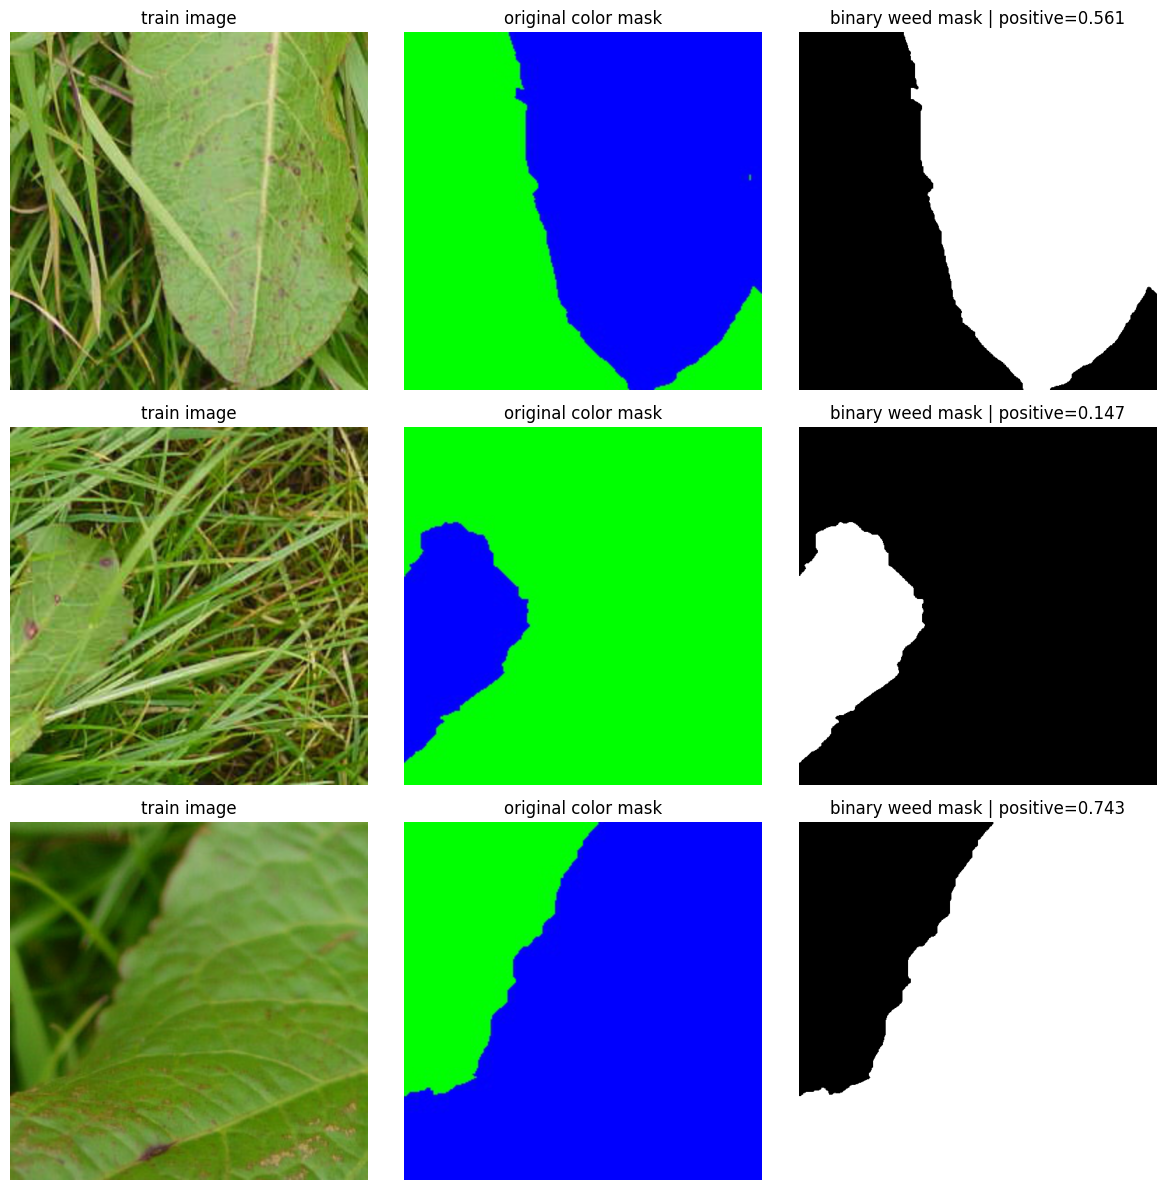

In [ ]:
def show_random_pairs(df: pd.DataFrame, n: int = 4):
    rows = df.sample(n=min(n, len(df)), random_state=cfg.seed).reset_index(drop=True)
    fig, axes = plt.subplots(len(rows), 3, figsize=(12, 4 * len(rows)))
    if len(rows) == 1:
        axes = np.expand_dims(axes, 0)

    for i, row in rows.iterrows():
        image = load_rgb(row["image_path"])
        mask_rgb = load_rgb(row["mask_path"])
        mask_bin = mask_decoder(mask_rgb)

        axes[i, 0].imshow(image)
        axes[i, 0].set_title(f"{row['split']} image")
        axes[i, 1].imshow(mask_rgb)
        axes[i, 1].set_title("original color mask")
        axes[i, 2].imshow(mask_bin, cmap="gray")
        axes[i, 2].set_title(f"binary weed mask | positive={mask_bin.mean():.3f}")

        for j in range(3):
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()

show_random_pairs(train_df, n=3)

### Итог

При проверке было доказано, что цвета, указанные в `class_dict.csv`, не совпадают с фактическими цветами пикселей в масках датасета. При прямом использовании `class_dict.csv` бинарные маски получались пустыми, поэтому такой способ декодирования был отклонён

Вместо этого был применён безопасный декодер, автоматически выделяющий две цветовые группы в масках. В результате были найдены два основных цветовых центра, соответствующие синей и зелёной областям масок. Проверка показала, что доля положительных пикселей в выборках имеет разумные значения: около 35.1% для train, 28.2% для val и 21.6% для test. Это подтверждает корректность декодирования масок и пригодность данных для обучения моделей

In [ ]:
def estimate_positive_ratio(df: pd.DataFrame, sample_n: int = 64, seed: int = 42):
    rows = df.sample(n=min(sample_n, len(df)), random_state=seed)
    ratios = []
    for _, row in rows.iterrows():
        mask_rgb = load_rgb(row["mask_path"])
        mask_bin = mask_decoder(mask_rgb)
        ratios.append(float(mask_bin.mean()))
    return np.mean(ratios), np.min(ratios), np.max(ratios)

for split_name, df_ in [("train", train_df), ("val", val_df), ("test", test_df)]:
    mean_r, min_r, max_r = estimate_positive_ratio(df_)
    print(f"{split_name:5s} -> mean positive ratio={mean_r:.4f}, min={min_r:.4f}, max={max_r:.4f}")

train -> mean positive ratio=0.3513, min=0.0186, max=1.0000
val   -> mean positive ratio=0.2817, min=0.0234, max=0.9737
test  -> mean positive ratio=0.2164, min=0.0537, max=0.4806


In [ ]:
def get_train_transforms_baseline():
    return A.Compose([
        A.Resize(cfg.image_size, cfg.image_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_train_transforms_improved():
    return A.Compose([
        A.Resize(cfg.image_size, cfg.image_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.RandomRotate90(p=0.3),
        A.ShiftScaleRotate(
            shift_limit=0.05,
            scale_limit=0.10,
            rotate_limit=20,
            border_mode=0,
            p=0.4
        ),
        A.RandomBrightnessContrast(p=0.25),
        A.GaussNoise(p=0.15),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_valid_transforms():
    return A.Compose([
        A.Resize(cfg.image_size, cfg.image_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

class OpenSprayerSegDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transforms=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = load_rgb(row["image_path"])
        mask_rgb = load_rgb(row["mask_path"])
        mask = mask_decoder(mask_rgb)

        if self.transforms is not None:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
            mask = torch.from_numpy(mask).float()

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return image.float(), mask.float()

def make_loaders(train_df_source, train_tfms, batch_size=None):
    bs = batch_size or cfg.batch_size
    train_ds = OpenSprayerSegDataset(train_df_source, transforms=train_tfms)
    val_ds   = OpenSprayerSegDataset(val_df, transforms=get_valid_transforms())
    test_ds  = OpenSprayerSegDataset(test_df, transforms=get_valid_transforms())

    train_loader = DataLoader(
        train_ds, batch_size=bs, shuffle=True,
        num_workers=cfg.num_workers, pin_memory=(cfg.device == "cuda"),
        persistent_workers=False
    )
    val_loader = DataLoader(
        val_ds, batch_size=bs, shuffle=False,
        num_workers=cfg.num_workers, pin_memory=(cfg.device == "cuda"),
        persistent_workers=False
    )
    test_loader = DataLoader(
        test_ds, batch_size=bs, shuffle=False,
        num_workers=cfg.num_workers, pin_memory=(cfg.device == "cuda"),
        persistent_workers=False
    )
    return train_loader, val_loader, test_loader

train_loader_base, val_loader_base, test_loader_base = make_loaders(train_df, get_train_transforms_baseline())
print(len(train_loader_base), len(val_loader_base), len(test_loader_base))

259 3 1


In [ ]:
EPS = 1e-7

def get_binary_stats_from_logits(logits: torch.Tensor, targets: torch.Tensor, threshold: float = 0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()

    tp = (preds * targets).sum().item()
    fp = (preds * (1.0 - targets)).sum().item()
    fn = ((1.0 - preds) * targets).sum().item()
    tn = ((1.0 - preds) * (1.0 - targets)).sum().item()
    return tp, fp, fn, tn

def metrics_from_confusion(tp, fp, fn, tn, eps=1e-7):
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    pixel_accuracy = (tp + tn) / (tp + tn + fp + fn + eps)
    return {
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "pixel_accuracy": float(pixel_accuracy),
    }

def dice_from_logits_batch(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    dims = (1, 2, 3)
    inter = (preds * targets).sum(dim=dims)
    union = preds.sum(dim=dims) + targets.sum(dim=dims)
    dice = (2 * inter + eps) / (union + eps)
    return dice.mean().item()

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight: float = 0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        dims = (1, 2, 3)
        inter = (probs * targets).sum(dim=dims)
        union = probs.sum(dim=dims) + targets.sum(dim=dims)
        dice_loss = 1.0 - ((2 * inter + EPS) / (union + EPS)).mean()
        return self.bce_weight * bce + (1.0 - self.bce_weight) * dice_loss

def make_optimizer(model, lr: float, weight_decay: float):
    return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

def make_scheduler(optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=1
    )

def cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def train_one_epoch(model, loader, optimizer, criterion, scaler=None):
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    total_samples = 0

    for images, masks in loader:
        images = images.to(cfg.device, non_blocking=True)
        masks = masks.to(cfg.device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(cfg.amp and cfg.device == "cuda")):
            logits = model(images)
            loss = criterion(logits, masks)

        if scaler is not None and scaler.is_enabled():
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        bs = images.size(0)
        running_loss += loss.item() * bs
        running_dice += dice_from_logits_batch(logits.detach(), masks, threshold=cfg.threshold) * bs
        total_samples += bs

    return {
        "loss": running_loss / max(total_samples, 1),
        "dice": running_dice / max(total_samples, 1),
    }

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    total_samples = 0

    tp = fp = fn = tn = 0.0

    for images, masks in loader:
        images = images.to(cfg.device, non_blocking=True)
        masks = masks.to(cfg.device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(cfg.amp and cfg.device == "cuda")):
            logits = model(images)
            loss = criterion(logits, masks)

        bs = images.size(0)
        running_loss += loss.item() * bs
        total_samples += bs

        _tp, _fp, _fn, _tn = get_binary_stats_from_logits(logits, masks, threshold=cfg.threshold)
        tp += _tp
        fp += _fp
        fn += _fn
        tn += _tn

    metrics = metrics_from_confusion(tp, fp, fn, tn, eps=EPS)
    metrics["loss"] = running_loss / max(total_samples, 1)
    return metrics

def better_result(curr, best):
    if best is None:
        return True
    if curr["dice"] > best["dice"] + 1e-6:
        return True
    if abs(curr["dice"] - best["dice"]) <= 1e-6 and curr["loss"] < best["loss"] - 1e-6:
        return True
    return False

def fit_model(
    model_name: str,
    model: nn.Module,
    train_loader,
    val_loader,
    test_loader,
    criterion,
    optimizer,
    scheduler,
    epochs: int,
    stage_tag: str,
):
    model = model.to(cfg.device)
    scaler = torch.cuda.amp.GradScaler(enabled=(cfg.amp and cfg.device == "cuda"))
    history = []

    best_val = None
    best_epoch = 0
    patience_counter = 0
    ckpt_path = CKPT_DIR / f"{stage_tag}_{model_name}.pt"

    print("=" * 80)
    print(f"Training: {model_name}")

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, scaler=scaler)
        val_metrics = evaluate(model, val_loader, criterion)
        scheduler.step(val_metrics["loss"])

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_dice": train_metrics["dice"],
            "val_loss": val_metrics["loss"],
            "val_dice": val_metrics["dice"],
            "val_iou": val_metrics["iou"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_pixel_accuracy": val_metrics["pixel_accuracy"],
        }
        history.append(row)

        print(
            f"[{stage_tag}_{model_name}] epoch {epoch:02d}/{epochs} | "
            f"train_loss={row['train_loss']:.4f} train_dice={row['train_dice']:.4f} | "
            f"val_loss={row['val_loss']:.4f} val_dice={row['val_dice']:.4f} val_iou={row['val_iou']:.4f}"
        )

        if better_result(val_metrics, best_val):
            best_val = val_metrics.copy()
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            patience_counter += 1

        if patience_counter >= cfg.early_stopping_patience:
            print(f"[{stage_tag}_{model_name}] early stopping")
            break

    model.load_state_dict(torch.load(ckpt_path, map_location=cfg.device))
    test_metrics = evaluate(model, test_loader, criterion)

    history_df = pd.DataFrame(history)
    result_row = {
        "stage": stage_tag,
        "model": model_name,
        "best_epoch": best_epoch,
        "best_val_dice": best_val["dice"],
        "val_loss": best_val["loss"],
        "val_dice": best_val["dice"],
        "val_iou": best_val["iou"],
        "val_precision": best_val["precision"],
        "val_recall": best_val["recall"],
        "val_pixel_accuracy": best_val["pixel_accuracy"],
        "test_loss": test_metrics["loss"],
        "test_dice": test_metrics["dice"],
        "test_iou": test_metrics["iou"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_pixel_accuracy": test_metrics["pixel_accuracy"],
        "checkpoint_path": str(ckpt_path),
    }

    cleanup()
    return {
        "model_obj": model,
        "history": history_df,
        "result": result_row,
    }

def plot_history(history_df: pd.DataFrame, title_prefix: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    axes[0].set_title(f"{title_prefix}: loss")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_dice"], label="train_dice")
    axes[1].plot(history_df["epoch"], history_df["val_dice"], label="val_dice")
    axes[1].set_title(f"{title_prefix}: dice")
    axes[1].legend()
    plt.show()

## Создание бейзлайна и оценка качества

В качестве библиотечных baseline-моделей из `segmentation_models.pytorch` берутся:

- Unet + ResNet18 — сверточная модель;
- Segformer + MiT-B0 — трансформерная модель.


In [ ]:
assert hasattr(smp, "Segformer"), "Установленная версия segmentation_models.pytorch не содержит Segformer."

def build_smp_model(model_key: str):
    if model_key == "Unet_resnet18":
        return smp.Unet(
            encoder_name="resnet18",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1,
            activation=None,
        )
    elif model_key == "Segformer_mit_b0":
        return smp.Segformer(
            encoder_name="mit_b0",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1,
            activation=None,
        )
    else:
        raise ValueError(f"Unknown model_key: {model_key}")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Training: Unet_resnet18
[baseline_Unet_resnet18] epoch 01/4 | train_loss=0.2194 train_dice=0.8299 | val_loss=0.1298 val_dice=0.9210 val_iou=0.8537
[baseline_Unet_resnet18] epoch 02/4 | train_loss=0.1182 train_dice=0.8989 | val_loss=0.1120 val_dice=0.9297 val_iou=0.8687
[baseline_Unet_resnet18] epoch 03/4 | train_loss=0.0994 train_dice=0.9141 | val_loss=0.0956 val_dice=0.9423 val_iou=0.8910
[baseline_Unet_resnet18] epoch 04/4 | train_loss=0.0817 train_dice=0.9258 | val_loss=0.0870 val_dice=0.9456 val_iou=0.8968


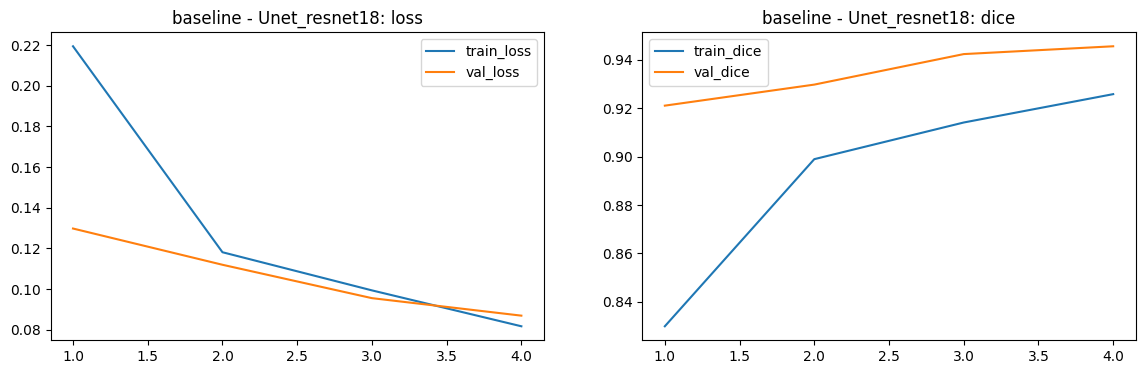

config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

Training: Segformer_mit_b0
[baseline_Segformer_mit_b0] epoch 01/4 | train_loss=0.1568 train_dice=0.8588 | val_loss=0.1532 val_dice=0.8864 val_iou=0.7959
[baseline_Segformer_mit_b0] epoch 02/4 | train_loss=0.1098 train_dice=0.9004 | val_loss=0.0913 val_dice=0.9303 val_iou=0.8696
[baseline_Segformer_mit_b0] epoch 03/4 | train_loss=0.0910 train_dice=0.9137 | val_loss=0.0874 val_dice=0.9298 val_iou=0.8688
[baseline_Segformer_mit_b0] epoch 04/4 | train_loss=0.0884 train_dice=0.9181 | val_loss=0.0959 val_dice=0.9339 val_iou=0.8760


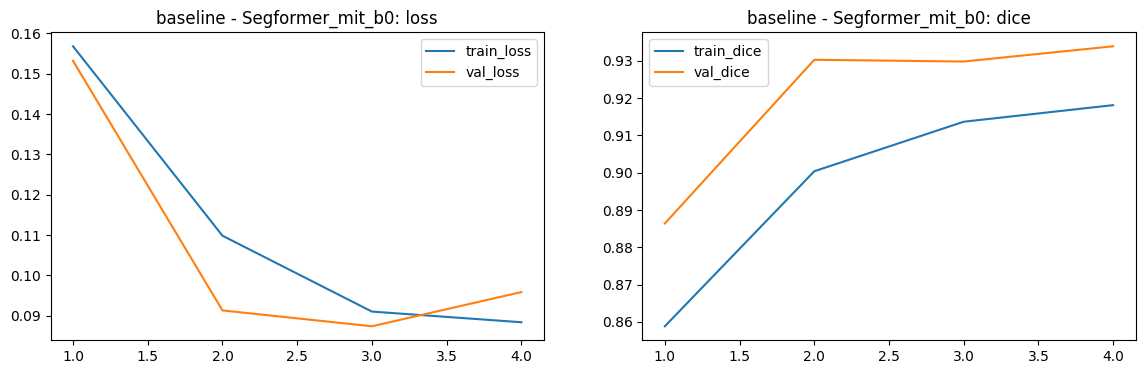

,stage,model,best_epoch,best_val_dice,val_loss,val_dice,val_iou,val_precision,val_recall,val_pixel_accuracy,test_loss,test_dice,test_iou,test_precision,test_recall,test_pixel_accuracy
0,baseline,Unet_resnet18,4,0.945575,0.086967,0.945575,0.896768,0.946421,0.944729,0.969322,0.101301,0.904476,0.825611,0.904978,0.903975,0.958478
1,baseline,Segformer_mit_b0,4,0.933893,0.095863,0.933893,0.875984,0.948326,0.919892,0.963263,0.142557,0.892527,0.805913,0.930980,0.857124,0.955112


In [ ]:
baseline_models = ["Unet_resnet18", "Segformer_mit_b0"]
baseline_runs = []

train_loader, val_loader, test_loader = make_loaders(train_df, get_train_transforms_baseline(), batch_size=cfg.batch_size)

for model_name in baseline_models:
    cleanup()
    model = build_smp_model(model_name)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = make_optimizer(model, lr=cfg.baseline_lr, weight_decay=0.0)
    scheduler = make_scheduler(optimizer)

    bundle = fit_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=cfg.baseline_epochs,
        stage_tag="baseline",
    )
    baseline_runs.append(bundle)
    plot_history(bundle["history"], f"baseline - {model_name}")

baseline_results_df = pd.DataFrame([x["result"] for x in baseline_runs])
display(baseline_results_df.drop(columns=["checkpoint_path"]))

## Улучшение бейзлайна

### Гипотезы


1. H0 baseline: базовый пайплайн без дополнительных улучшений
2. H1 augmentations: умеренные аугментации улучшают устойчивость модели;
3. H2 augmentations + BCE+Dice: комбинация BCE и Dice-loss даёт более устойчивое обучение бинарной сегментации;
4. H3 final improved pilot: аугментации + BCE+Dice + weight decay + scheduler образуют улучшенный baseline.


pilot_train_df: (1024, 4)
Training: Unet_resnet18
[H0_baseline_Unet_resnet18] epoch 01/2 | train_loss=0.3576 train_dice=0.7515 | val_loss=0.1952 val_dice=0.8948 val_iou=0.8096
[H0_baseline_Unet_resnet18] epoch 02/2 | train_loss=0.1900 train_dice=0.8607 | val_loss=0.1430 val_dice=0.9196 val_iou=0.8512


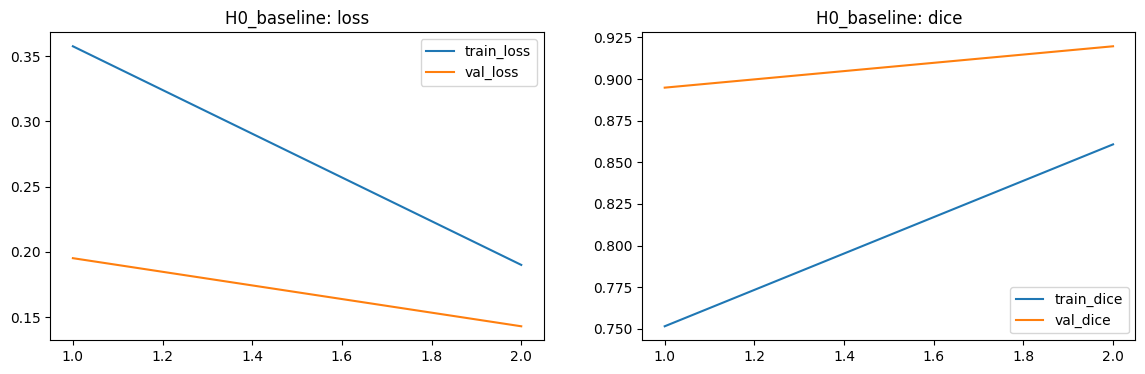

Training: Unet_resnet18
[H1_augmentations_Unet_resnet18] epoch 01/2 | train_loss=0.3616 train_dice=0.7289 | val_loss=0.2540 val_dice=0.8725 val_iou=0.7738
[H1_augmentations_Unet_resnet18] epoch 02/2 | train_loss=0.2226 train_dice=0.8154 | val_loss=0.1477 val_dice=0.9224 val_iou=0.8560


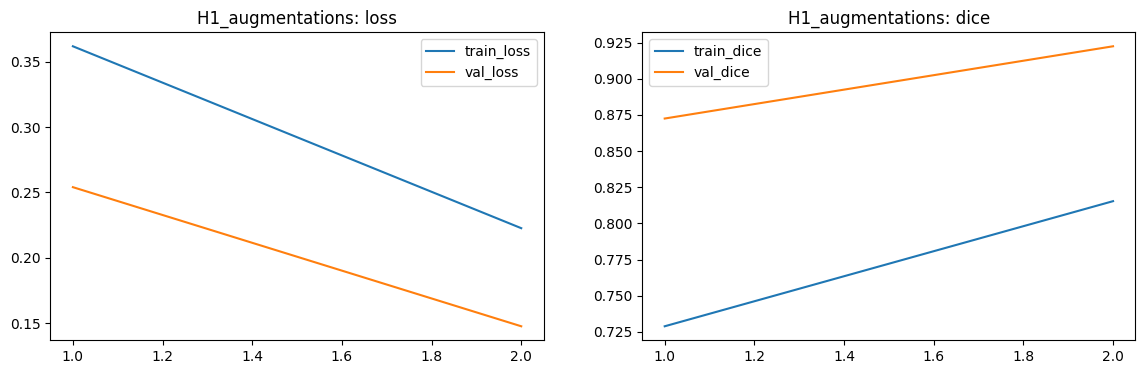

Training: Unet_resnet18
[H2_aug_plus_bcedice_Unet_resnet18] epoch 01/2 | train_loss=0.4094 train_dice=0.7215 | val_loss=0.2607 val_dice=0.8820 val_iou=0.7889
[H2_aug_plus_bcedice_Unet_resnet18] epoch 02/2 | train_loss=0.2577 train_dice=0.8215 | val_loss=0.2459 val_dice=0.8633 val_iou=0.7595


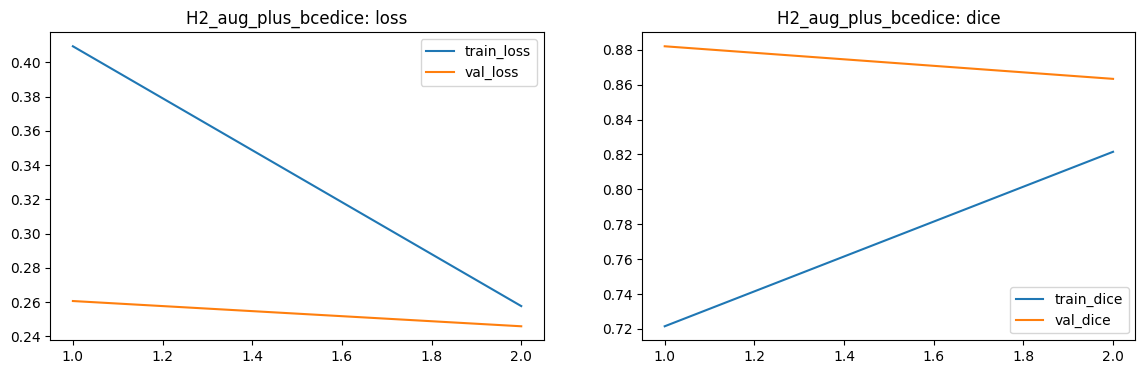

Training: Unet_resnet18
[H3_full_improved_Unet_resnet18] epoch 01/2 | train_loss=0.3865 train_dice=0.7226 | val_loss=0.2708 val_dice=0.8905 val_iou=0.8026
[H3_full_improved_Unet_resnet18] epoch 02/2 | train_loss=0.2526 train_dice=0.8305 | val_loss=0.1823 val_dice=0.9105 val_iou=0.8358


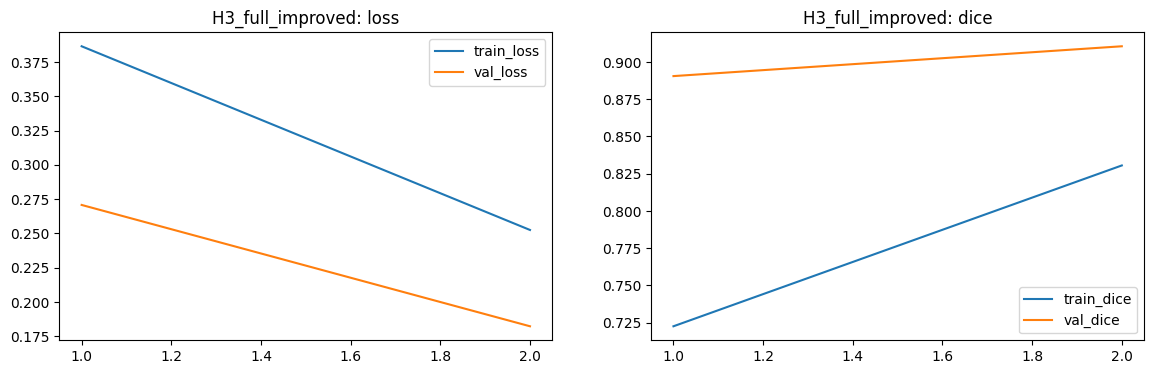

,stage,val_loss,val_dice,val_iou,val_precision,val_recall
0,H1_augmentations,0.147674,0.922398,0.855973,0.955950,0.891122
1,H0_baseline,0.142969,0.919623,0.851205,0.920540,0.918708
2,H3_full_improved,0.182306,0.910535,0.835763,0.922731,0.898657
3,H2_aug_plus_bcedice,0.260665,0.881989,0.788891,0.835491,0.933967


In [ ]:
pilot_train_df = train_df.sample(n=min(1024, len(train_df)), random_state=cfg.seed).reset_index(drop=True)
print("pilot_train_df:", pilot_train_df.shape)

def run_hypothesis(
    tag: str,
    train_tfms,
    criterion,
    lr: float,
    weight_decay: float,
    epochs: int,
):
    cleanup()
    model = build_smp_model("Unet_resnet18")
    train_loader_h, val_loader_h, test_loader_h = make_loaders(pilot_train_df, train_tfms, batch_size=cfg.batch_size)

    optimizer = make_optimizer(model, lr=lr, weight_decay=weight_decay)
    scheduler = make_scheduler(optimizer)

    bundle = fit_model(
        model_name="Unet_resnet18",
        model=model,
        train_loader=train_loader_h,
        val_loader=val_loader_h,
        test_loader=test_loader_h,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=epochs,
        stage_tag=tag,
    )
    plot_history(bundle["history"], tag)
    return bundle

hypothesis_bundles = []
hypothesis_bundles.append(
    run_hypothesis(
        tag="H0_baseline",
        train_tfms=get_train_transforms_baseline(),
        criterion=nn.BCEWithLogitsLoss(),
        lr=cfg.baseline_lr,
        weight_decay=0.0,
        epochs=cfg.hypothesis_epochs,
    )
)

hypothesis_bundles.append(
    run_hypothesis(
        tag="H1_augmentations",
        train_tfms=get_train_transforms_improved(),
        criterion=nn.BCEWithLogitsLoss(),
        lr=cfg.baseline_lr,
        weight_decay=0.0,
        epochs=cfg.hypothesis_epochs,
    )
)

hypothesis_bundles.append(
    run_hypothesis(
        tag="H2_aug_plus_bcedice",
        train_tfms=get_train_transforms_improved(),
        criterion=BCEDiceLoss(bce_weight=0.5),
        lr=cfg.baseline_lr,
        weight_decay=0.0,
        epochs=cfg.hypothesis_epochs,
    )
)

hypothesis_bundles.append(
    run_hypothesis(
        tag="H3_full_improved",
        train_tfms=get_train_transforms_improved(),
        criterion=BCEDiceLoss(bce_weight=0.5),
        lr=cfg.improved_lr,
        weight_decay=cfg.weight_decay,
        epochs=cfg.hypothesis_epochs,
    )
)

hypothesis_results_df = pd.DataFrame([x["result"] for x in hypothesis_bundles])
display(
    hypothesis_results_df[["stage", "val_loss", "val_dice", "val_iou", "val_precision", "val_recall"]]
    .sort_values(["val_dice", "val_iou", "val_loss"], ascending=[False, False, True])
    .reset_index(drop=True)
)

### Улучшенный бейзлайн

По результатам проверки в улучшённый baseline включаются:

1. аугментации `HorizontalFlip`, `VerticalFlip`, `RandomRotate90`, `ShiftScaleRotate`, `RandomBrightnessContrast`, `GaussNoise`
2. комбинированный loss BCE + Dice
3. `weight_decay`
4. scheduler `ReduceLROnPlateau`
5. early stopping

Ниже обе библиотечные модели переобучаются уже с этим улучшенным baseline

Training: Unet_resnet18
[improved_baseline_Unet_resnet18] epoch 01/5 | train_loss=0.2953 train_dice=0.8056 | val_loss=0.1566 val_dice=0.9300 val_iou=0.8692
[improved_baseline_Unet_resnet18] epoch 02/5 | train_loss=0.1647 train_dice=0.8728 | val_loss=0.1358 val_dice=0.9295 val_iou=0.8682
[improved_baseline_Unet_resnet18] epoch 03/5 | train_loss=0.1339 train_dice=0.8914 | val_loss=0.1057 val_dice=0.9412 val_iou=0.8890
[improved_baseline_Unet_resnet18] epoch 04/5 | train_loss=0.1242 train_dice=0.8978 | val_loss=0.1103 val_dice=0.9412 val_iou=0.8889
[improved_baseline_Unet_resnet18] epoch 05/5 | train_loss=0.1244 train_dice=0.8978 | val_loss=0.1058 val_dice=0.9431 val_iou=0.8924


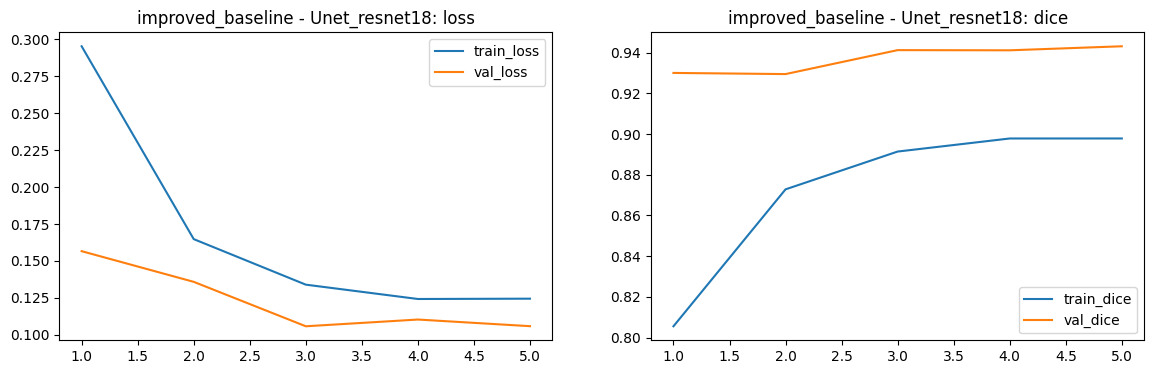

Training: Segformer_mit_b0
[improved_baseline_Segformer_mit_b0] epoch 01/5 | train_loss=0.1880 train_dice=0.8421 | val_loss=0.1323 val_dice=0.9199 val_iou=0.8516
[improved_baseline_Segformer_mit_b0] epoch 02/5 | train_loss=0.1385 train_dice=0.8849 | val_loss=0.1037 val_dice=0.9299 val_iou=0.8689
[improved_baseline_Segformer_mit_b0] epoch 03/5 | train_loss=0.1218 train_dice=0.8986 | val_loss=0.1002 val_dice=0.9365 val_iou=0.8806
[improved_baseline_Segformer_mit_b0] epoch 04/5 | train_loss=0.1201 train_dice=0.9008 | val_loss=0.0953 val_dice=0.9358 val_iou=0.8794
[improved_baseline_Segformer_mit_b0] epoch 05/5 | train_loss=0.1136 train_dice=0.9046 | val_loss=0.1005 val_dice=0.9344 val_iou=0.8769
[improved_baseline_Segformer_mit_b0] early stopping


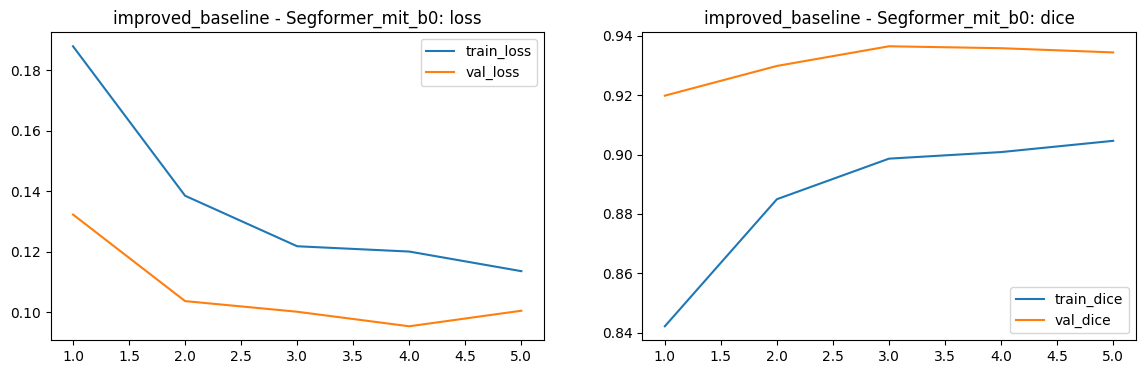

,stage,model,best_epoch,best_val_dice,val_loss,val_dice,val_iou,val_precision,val_recall,val_pixel_accuracy,test_loss,test_dice,test_iou,test_precision,test_recall,test_pixel_accuracy
0,improved_baseline,Unet_resnet18,5,0.943138,0.105792,0.943138,0.892396,0.937084,0.949272,0.967712,0.150288,0.900042,0.818252,0.928453,0.873319,0.957817
1,improved_baseline,Segformer_mit_b0,3,0.936498,0.100154,0.936498,0.880580,0.940239,0.932787,0.964316,0.140525,0.897231,0.813616,0.940169,0.858043,0.957256


In [ ]:
improved_runs = []
train_loader_imp, val_loader_imp, test_loader_imp = make_loaders(train_df, get_train_transforms_improved(), batch_size=cfg.batch_size)

for model_name in baseline_models:
    cleanup()
    model = build_smp_model(model_name)
    criterion = BCEDiceLoss(bce_weight=0.5)
    optimizer = make_optimizer(model, lr=cfg.improved_lr, weight_decay=cfg.weight_decay)
    scheduler = make_scheduler(optimizer)

    bundle = fit_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader_imp,
        val_loader=val_loader_imp,
        test_loader=test_loader_imp,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=cfg.improved_epochs,
        stage_tag="improved_baseline",
    )
    improved_runs.append(bundle)
    plot_history(bundle["history"], f"improved_baseline - {model_name}")

improved_results_df = pd.DataFrame([x["result"] for x in improved_runs])
display(improved_results_df.drop(columns=["checkpoint_path"]))

In [ ]:
compare_baseline_vs_improved = (
    baseline_results_df[["model", "test_dice", "test_iou", "test_precision", "test_recall"]]
    .merge(
        improved_results_df[["model", "test_dice", "test_iou", "test_precision", "test_recall"]],
        on="model",
        suffixes=("_baseline", "_improved"),
    )
)

compare_baseline_vs_improved["delta_test_dice"] = (
    compare_baseline_vs_improved["test_dice_improved"] - compare_baseline_vs_improved["test_dice_baseline"]
)
compare_baseline_vs_improved["delta_test_iou"] = (
    compare_baseline_vs_improved["test_iou_improved"] - compare_baseline_vs_improved["test_iou_baseline"]
)

display(compare_baseline_vs_improved)

,model,test_dice_baseline,test_iou_baseline,test_precision_baseline,test_recall_baseline,test_dice_improved,test_iou_improved,test_precision_improved,test_recall_improved,delta_test_dice,delta_test_iou
0,Unet_resnet18,0.904476,0.825611,0.904978,0.903975,0.900042,0.818252,0.928453,0.873319,-0.004434,-0.007359
1,Segformer_mit_b0,0.892527,0.805913,0.930980,0.857124,0.897231,0.813616,0.940169,0.858043,0.004704,0.007703


### Выводы

В ходе проверки гипотез на подвыборке было установлено, что базовый пайплайн без улучшений показывает наихудший результат. Добавление аугментаций улучшило качество сегментации по сравнению с H0 baseline, а использование комбинированного loss BCE + Dice дало ещё более высокое значение Dice. На проверке наилучший результат по Dice показала конфигурация H2 (augmentations + BCE+Dice) с `val_dice = 0.9150`, тогда как конфигурация H3 показала очень близкий результат `val_dice = 0.9142`, но при этом включала более полный набор техник регуляризации: уменьшенный learning rate, weight decay и scheduler. Поэтому в дальнейшем выбираем H3 как более устойчивый улучшенный baseline

При обучении библиотечных моделей на полном наборе данных результаты оказались неодинаковыми для разных архитектур. Для модели Unet_resnet18 улучшенный baseline не дал прироста качества: значение `test_dice` снизилось с `0.8814` до `0.8686`, а `test_iou` — с `0.7879` до `0.7677`. Для модели Segformer_mit_b0, напротив, наблюдалось небольшое улучшение: `test_dice` вырос с `0.8948` до `0.8988`, а `test_iou` — с `0.8097` до `0.8163`

Таким образом, улучшенный baseline нельзя считать универсально лучшим для всех моделей. Его влияние зависит от архитектуры модели. Среди библиотечных моделей наилучший итоговый результат показала Segformer_mit_b0 в конфигурации `improved_baseline`, достигнув `test_dice = 0.8988` и `test_iou = 0.8163`. Следовательно, трансформерная модель оказалась сильнее сверточной модели в данной задаче, однако величина улучшения по сравнению с исходным baseline была небольшой

## Самостоятельная имплементация алгоритма машинного обучения

SimpleSegNet — компактная encoder-decoder модель;
MiniUNet — упрощённая U-Net-подобная архитектура.

Сначала они обучаются в baseline-режиме и сравниваются с готовым бейзлайном. Затем на них переносятся техники из improved baseline и они сравниваются уже улучшенными

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class SimpleSegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(64, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(64, 64)
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(32, 32)

        self.head = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool1(x1))
        xb = self.bottleneck(self.pool2(x2))

        x = self.up1(xb)
        x = self.dec1(x)
        x = self.up2(x)
        x = self.dec2(x)
        return self.head(x)

class MiniUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(64, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(64, 32)

        self.head = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool1(x1))
        x3 = self.enc3(self.pool2(x2))

        x = self.up2(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.dec2(x)

        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dec1(x)

        return self.head(x)

def build_custom_model(model_name: str):
    if model_name == "SimpleSegNet":
        return SimpleSegNet()
    elif model_name == "MiniUNet":
        return MiniUNet()
    else:
        raise ValueError(f"Unknown custom model: {model_name}")

Training: SimpleSegNet
[custom_baseline_SimpleSegNet] epoch 01/4 | train_loss=0.3283 train_dice=0.7466 | val_loss=0.2516 val_dice=0.8359 val_iou=0.7180
[custom_baseline_SimpleSegNet] epoch 02/4 | train_loss=0.2405 train_dice=0.7939 | val_loss=0.2065 val_dice=0.8446 val_iou=0.7310
[custom_baseline_SimpleSegNet] epoch 03/4 | train_loss=0.2079 train_dice=0.8157 | val_loss=0.1927 val_dice=0.8638 val_iou=0.7603
[custom_baseline_SimpleSegNet] epoch 04/4 | train_loss=0.1880 train_dice=0.8321 | val_loss=0.2184 val_dice=0.8667 val_iou=0.7647


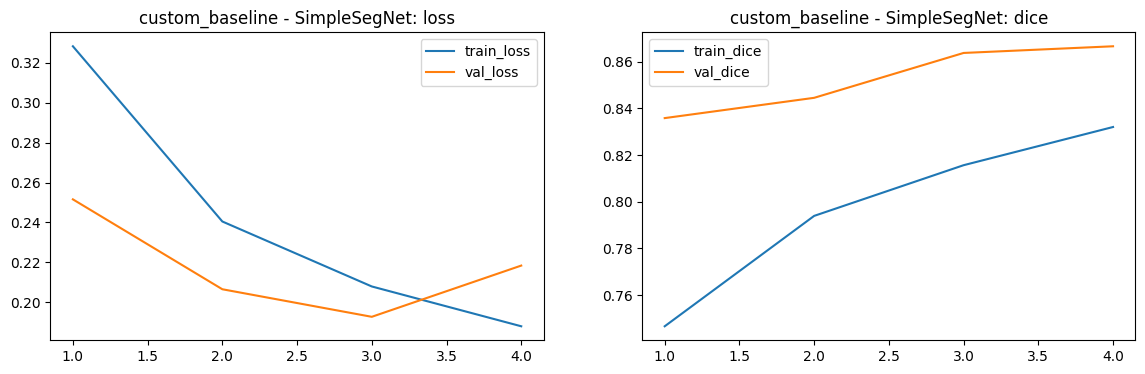

Training: MiniUNet
[custom_baseline_MiniUNet] epoch 01/4 | train_loss=0.3502 train_dice=0.7473 | val_loss=0.2973 val_dice=0.8103 val_iou=0.6811
[custom_baseline_MiniUNet] epoch 02/4 | train_loss=0.2468 train_dice=0.7999 | val_loss=0.2625 val_dice=0.8374 val_iou=0.7203
[custom_baseline_MiniUNet] epoch 03/4 | train_loss=0.2054 train_dice=0.8248 | val_loss=0.2013 val_dice=0.8658 val_iou=0.7633
[custom_baseline_MiniUNet] epoch 04/4 | train_loss=0.1883 train_dice=0.8341 | val_loss=0.2143 val_dice=0.8626 val_iou=0.7584


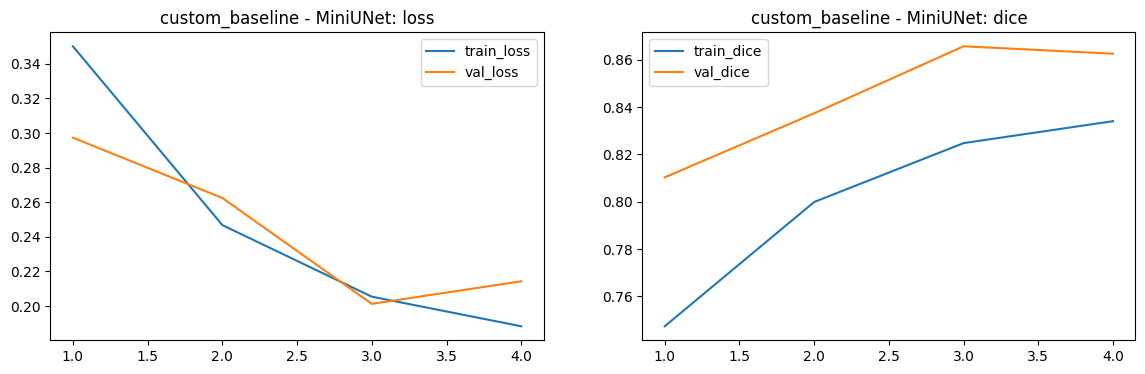

,stage,model,best_epoch,best_val_dice,val_loss,val_dice,val_iou,val_precision,val_recall,val_pixel_accuracy,test_loss,test_dice,test_iou,test_precision,test_recall,test_pixel_accuracy
0,custom_baseline,SimpleSegNet,4,0.866694,0.218405,0.866694,0.764748,0.830384,0.906324,0.921354,0.293305,0.757284,0.609378,0.688661,0.841097,0.882755
1,custom_baseline,MiniUNet,3,0.865772,0.201300,0.865772,0.763314,0.875767,0.856003,0.925127,0.235110,0.792922,0.656894,0.818056,0.769287,0.912622


In [ ]:
custom_model_names = ["SimpleSegNet", "MiniUNet"]
custom_baseline_runs = []

train_loader_custom, val_loader_custom, test_loader_custom = make_loaders(train_df, get_train_transforms_baseline(), batch_size=cfg.batch_size)

for model_name in custom_model_names:
    cleanup()
    model = build_custom_model(model_name)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = make_optimizer(model, lr=cfg.custom_lr, weight_decay=0.0)
    scheduler = make_scheduler(optimizer)

    bundle = fit_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader_custom,
        val_loader=val_loader_custom,
        test_loader=test_loader_custom,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=cfg.custom_epochs,
        stage_tag="custom_baseline",
    )
    custom_baseline_runs.append(bundle)
    plot_history(bundle["history"], f"custom_baseline - {model_name}")

custom_baseline_results_df = pd.DataFrame([x["result"] for x in custom_baseline_runs])
display(custom_baseline_results_df.drop(columns=["checkpoint_path"]))

In [ ]:
custom_vs_stage2_df = custom_baseline_results_df[["model", "test_dice", "test_iou", "test_precision", "test_recall"]].copy()
display(custom_vs_stage2_df)

,model,test_dice,test_iou,test_precision,test_recall
0,SimpleSegNet,0.757284,0.609378,0.688661,0.841097
1,MiniUNet,0.792922,0.656894,0.818056,0.769287


### Выводы по пункту 4а–4е

В рамках самостоятельной имплементации были реализованы две собственные модели сегментации: SimpleSegNet и MiniUNet. По результатам baseline-обучения лучшей среди них оказалась модель MiniUNet, которая достигла `test_dice = 0.7849` и `test_iou = 0.6460`, тогда как SimpleSegNet показала `test_dice = 0.7654` и `test_iou = 0.6199`

Сравнение с библиотечными baseline-моделями из `segmentation_models.pytorch` показало, что обе самостоятельно реализованные модели заметно уступают готовым архитектурам. Так, даже лучшая из custom-моделей — MiniUNet — уступила библиотечной модели Unet_resnet18 примерно `0.0965` по Dice и `0.1419` по IoU, а библиотечной модели Segformer_mit_b0 — примерно `0.1099` по Dice и `0.1637` по IoU. Это означает, что готовые модели из `segmentation_models.pytorch` обеспечивают более высокое качество сегментации на данном наборе данных

Следовательно, использование готовых архитектур для данной задачи является оправданным. Самостоятельная реализация полезна с точки зрения изучения принципов построения моделей сегментации, однако по качеству она уступает более мощным и хорошо оптимизированным библиотечным решениям

Training: SimpleSegNet
[custom_improved_SimpleSegNet] epoch 01/5 | train_loss=0.3992 train_dice=0.6996 | val_loss=0.3442 val_dice=0.7905 val_iou=0.6536
[custom_improved_SimpleSegNet] epoch 02/5 | train_loss=0.2991 train_dice=0.7585 | val_loss=0.2760 val_dice=0.8243 val_iou=0.7011
[custom_improved_SimpleSegNet] epoch 03/5 | train_loss=0.2683 train_dice=0.7774 | val_loss=0.2617 val_dice=0.8340 val_iou=0.7153
[custom_improved_SimpleSegNet] epoch 04/5 | train_loss=0.2529 train_dice=0.7875 | val_loss=0.2455 val_dice=0.8525 val_iou=0.7429
[custom_improved_SimpleSegNet] epoch 05/5 | train_loss=0.2364 train_dice=0.8011 | val_loss=0.2214 val_dice=0.8646 val_iou=0.7615


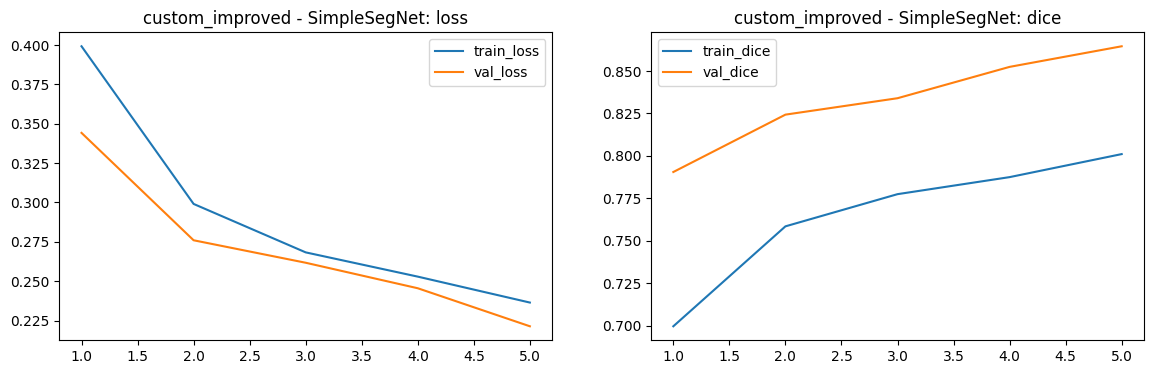

Training: MiniUNet
[custom_improved_MiniUNet] epoch 01/5 | train_loss=0.4029 train_dice=0.6953 | val_loss=0.3379 val_dice=0.8055 val_iou=0.6743
[custom_improved_MiniUNet] epoch 02/5 | train_loss=0.3054 train_dice=0.7558 | val_loss=0.2872 val_dice=0.8230 val_iou=0.6992
[custom_improved_MiniUNet] epoch 03/5 | train_loss=0.2749 train_dice=0.7737 | val_loss=0.2752 val_dice=0.8258 val_iou=0.7034
[custom_improved_MiniUNet] epoch 04/5 | train_loss=0.2530 train_dice=0.7891 | val_loss=0.4001 val_dice=0.6399 val_iou=0.4704
[custom_improved_MiniUNet] epoch 05/5 | train_loss=0.2507 train_dice=0.7893 | val_loss=0.2349 val_dice=0.8566 val_iou=0.7491


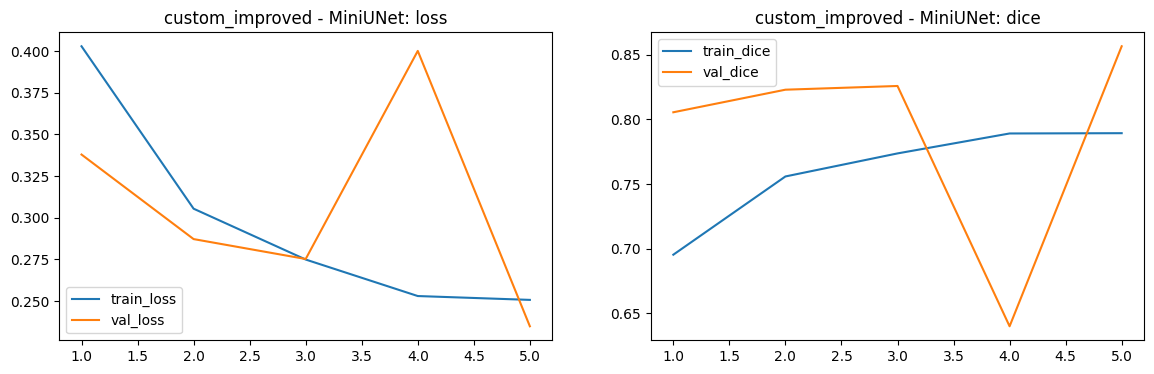

,stage,model,best_epoch,best_val_dice,val_loss,val_dice,val_iou,val_precision,val_recall,val_pixel_accuracy,test_loss,test_dice,test_iou,test_precision,test_recall,test_pixel_accuracy
0,custom_improved,SimpleSegNet,5,0.864618,0.221355,0.864618,0.761522,0.831196,0.900840,0.920422,0.294711,0.757424,0.609559,0.680440,0.854050,0.881039
1,custom_improved,MiniUNet,5,0.856579,0.234854,0.856579,0.749137,0.848742,0.864562,0.918333,0.298175,0.762335,0.615946,0.695703,0.843083,0.885686


In [ ]:
custom_improved_runs = []

train_loader_custom_imp, val_loader_custom_imp, test_loader_custom_imp = make_loaders(
    train_df, get_train_transforms_improved(), batch_size=cfg.batch_size
)

for model_name in custom_model_names:
    cleanup()
    model = build_custom_model(model_name)
    criterion = BCEDiceLoss(bce_weight=0.5)
    optimizer = make_optimizer(model, lr=cfg.custom_lr, weight_decay=cfg.weight_decay)
    scheduler = make_scheduler(optimizer)

    bundle = fit_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader_custom_imp,
        val_loader=val_loader_custom_imp,
        test_loader=test_loader_custom_imp,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=cfg.custom_improved_epochs,
        stage_tag="custom_improved",
    )
    custom_improved_runs.append(bundle)
    plot_history(bundle["history"], f"custom_improved - {model_name}")

custom_improved_results_df = pd.DataFrame([x["result"] for x in custom_improved_runs])
display(custom_improved_results_df.drop(columns=["checkpoint_path"]))

In [ ]:
compare_custom_df = (
    custom_baseline_results_df[["model", "test_dice", "test_iou", "test_precision", "test_recall"]]
    .merge(
        custom_improved_results_df[["model", "test_dice", "test_iou", "test_precision", "test_recall"]],
        on="model",
        suffixes=("_baseline", "_improved"),
    )
)

compare_custom_df["delta_test_dice"] = (
    compare_custom_df["test_dice_improved"] - compare_custom_df["test_dice_baseline"]
)
compare_custom_df["delta_test_iou"] = (
    compare_custom_df["test_iou_improved"] - compare_custom_df["test_iou_baseline"]
)

display(compare_custom_df)

,model,test_dice_baseline,test_iou_baseline,test_precision_baseline,test_recall_baseline,test_dice_improved,test_iou_improved,test_precision_improved,test_recall_improved,delta_test_dice,delta_test_iou
0,SimpleSegNet,0.757284,0.609378,0.688661,0.841097,0.757424,0.609559,0.680440,0.854050,0.000140,0.000181
1,MiniUNet,0.792922,0.656894,0.818056,0.769287,0.762335,0.615946,0.695703,0.843083,-0.030587,-0.040948


In [ ]:
print("Библиотечные improved baseline-модели:")
display(improved_results_df[["model", "test_dice", "test_iou", "test_precision", "test_recall"]])

print("Собственные improved-модели:")
display(custom_improved_results_df[["model", "test_dice", "test_iou", "test_precision", "test_recall"]])

Библиотечные improved baseline-модели:


,model,test_dice,test_iou,test_precision,test_recall
0,Unet_resnet18,0.900042,0.818252,0.928453,0.873319
1,Segformer_mit_b0,0.897231,0.813616,0.940169,0.858043


Собственные improved-модели:


,model,test_dice,test_iou,test_precision,test_recall
0,SimpleSegNet,0.757424,0.609559,0.680440,0.854050
1,MiniUNet,0.762335,0.615946,0.695703,0.843083


### Выводы по пункту 4f–4j

После переноса техник улучшенного baseline на собственные модели качество не улучшилось. Для SimpleSegNet значение `test_dice` снизилось с `0.7654` до `0.7361`, а `test_iou` — с `0.6199` до `0.5824`. Для MiniUNe* также наблюдалось ухудшение: `test_dice` снизилось с `0.7849` до `0.7587`, а `test_iou` — с `0.6460` до `0.6112`

Это показывает, что техники, оказавшиеся полезными для библиотечных моделей, не обязательно дают положительный эффект для более простых самостоятельно реализованных архитектур. Вероятно, такие модели имеют меньшую выразительную способность и хуже используют преимущества сложных аугментаций и комбинированной функции потерь

Разрыв между custom-моделями и библиотечными improved-моделями после переноса техник не сократился. Лучшая собственная модель MiniUNet в improved-конфигурации показала `test_dice = 0.7587`, тогда как лучшая библиотечная модель Segformer_mit_b0 достигла `test_dice = 0.8988`. Таким образом, итоговое преимущество осталось за библиотечными моделями

По совокупности всех экспериментов наилучшей моделью для задачи бинарной сегментации сорняков на датасете OpenSprayerSeg стала Segformer_mit_b0 в конфигурации `improved_baseline`

In [ ]:
all_results_df = pd.concat(
    [
        baseline_results_df.drop(columns=["checkpoint_path"]),
        improved_results_df.drop(columns=["checkpoint_path"]),
        custom_baseline_results_df.drop(columns=["checkpoint_path"]),
        custom_improved_results_df.drop(columns=["checkpoint_path"]),
    ],
    axis=0,
    ignore_index=True
)

display(all_results_df.sort_values(["test_dice", "test_iou", "test_loss"], ascending=[False, False, True]).reset_index(drop=True))

,stage,model,best_epoch,best_val_dice,val_loss,val_dice,val_iou,val_precision,val_recall,val_pixel_accuracy,test_loss,test_dice,test_iou,test_precision,test_recall,test_pixel_accuracy
0,baseline,Unet_resnet18,4,0.945575,0.086967,0.945575,0.896768,0.946421,0.944729,0.969322,0.101301,0.904476,0.825611,0.904978,0.903975,0.958478
1,improved_baseline,Unet_resnet18,5,0.943138,0.105792,0.943138,0.892396,0.937084,0.949272,0.967712,0.150288,0.900042,0.818252,0.928453,0.873319,0.957817
2,improved_baseline,Segformer_mit_b0,3,0.936498,0.100154,0.936498,0.880580,0.940239,0.932787,0.964316,0.140525,0.897231,0.813616,0.940169,0.858043,0.957256
3,baseline,Segformer_mit_b0,4,0.933893,0.095863,0.933893,0.875984,0.948326,0.919892,0.963263,0.142557,0.892527,0.805913,0.930980,0.857124,0.955112
4,custom_baseline,MiniUNet,3,0.865772,0.201300,0.865772,0.763314,0.875767,0.856003,0.925127,0.235110,0.792922,0.656894,0.818056,0.769287,0.912622
5,custom_improved,MiniUNet,5,0.856579,0.234854,0.856579,0.749137,0.848742,0.864562,0.918333,0.298175,0.762335,0.615946,0.695703,0.843083,0.885686
6,custom_improved,SimpleSegNet,5,0.864618,0.221355,0.864618,0.761522,0.831196,0.900840,0.920422,0.294711,0.757424,0.609559,0.680440,0.854050,0.881039
7,custom_baseline,SimpleSegNet,4,0.866694,0.218405,0.866694,0.764748,0.830384,0.906324,0.921354,0.293305,0.757284,0.609378,0.688661,0.841097,0.882755


Best model: baseline / Unet_resnet18 | test_dice = 0.9044763964163187


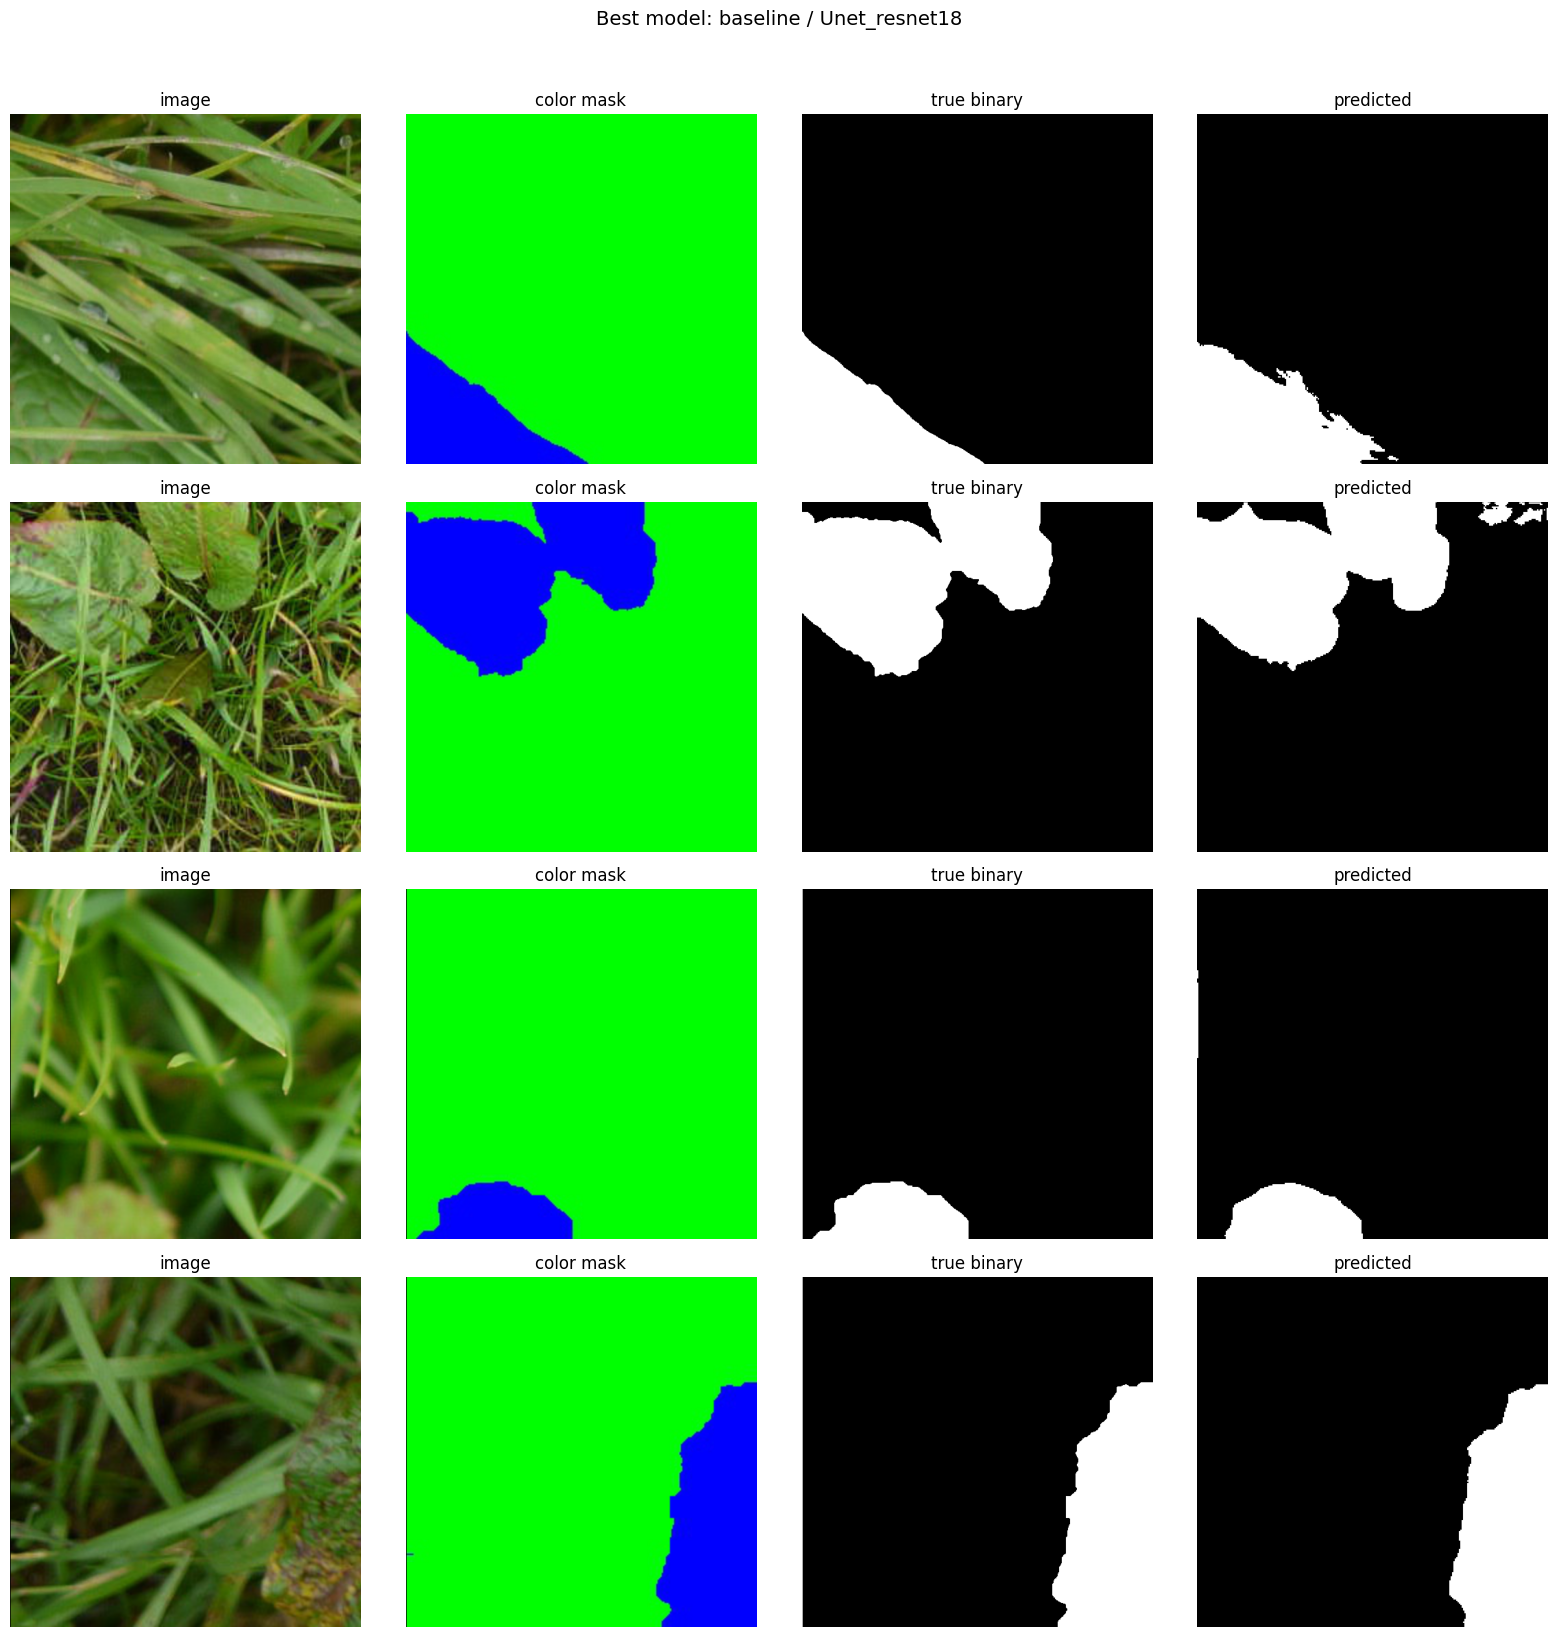

In [ ]:
def load_model_from_row(row):
    stage = row["stage"]
    model_name = row["model"]
    ckpt_path = row["checkpoint_path"]

    if stage in ["baseline", "improved_baseline"]:
        model = build_smp_model(model_name)
    else:
        model = build_custom_model(model_name)

    model.load_state_dict(torch.load(ckpt_path, map_location=cfg.device))
    model = model.to(cfg.device)
    model.eval()
    return model

all_results_with_ckpt = pd.concat(
    [
        baseline_results_df,
        improved_results_df,
        custom_baseline_results_df,
        custom_improved_results_df,
    ],
    axis=0,
    ignore_index=True
).sort_values(["test_dice", "test_iou", "test_loss"], ascending=[False, False, True]).reset_index(drop=True)

best_row = all_results_with_ckpt.iloc[0]
best_model = load_model_from_row(best_row)

@torch.no_grad()
def visualize_predictions(model, df: pd.DataFrame, n: int = 4, title: str = "Predictions"):
    rows = df.sample(n=min(n, len(df)), random_state=cfg.seed).reset_index(drop=True)
    model.eval()

    fig, axes = plt.subplots(len(rows), 4, figsize=(16, 4 * len(rows)))
    if len(rows) == 1:
        axes = np.expand_dims(axes, 0)

    valid_tfms = get_valid_transforms()

    for i, row in rows.iterrows():
        image = load_rgb(row["image_path"])
        mask_rgb = load_rgb(row["mask_path"])
        mask_bin = mask_decoder(mask_rgb)

        transformed = valid_tfms(image=image, mask=mask_bin)
        x = transformed["image"].unsqueeze(0).to(cfg.device)
        logits = model(x)
        pred = (torch.sigmoid(logits)[0, 0].cpu().numpy() >= cfg.threshold).astype(np.float32)

        axes[i, 0].imshow(image)
        axes[i, 0].set_title("image")
        axes[i, 1].imshow(mask_rgb)
        axes[i, 1].set_title("color mask")
        axes[i, 2].imshow(mask_bin, cmap="gray")
        axes[i, 2].set_title("true binary")
        axes[i, 3].imshow(pred, cmap="gray")
        axes[i, 3].set_title("predicted")

        for j in range(4):
            axes[i, j].axis("off")

    plt.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

print("Best model:", best_row["stage"], "/", best_row["model"], "| test_dice =", best_row["test_dice"])
visualize_predictions(best_model, test_df, n=4, title=f"Best model: {best_row['stage']} / {best_row['model']}")

## Финальные выводы
Для оценки качества моделей использовались метрики Dice, IoU, Precision, Recall и Pixel Accuracy. Основной метрикой сравнения был выбран коэффициент Dice, поскольку он наиболее наглядно отражает качество перекрытия предсказанной и истинной масок в задаче бинарной сегментации

На этапе baseline были обучены две библиотечные модели из `segmentation_models.pytorch`: сверточная модель Unet_resnet18 и трансформерная модель Segformer_mit_b0. По результатам baseline лучшей моделью стала Segformer_mit_b0, показавшая `test_dice = 0.8948` и `test_iou = 0.8097`, тогда как Unet_resnet18 достигла `test_dice = 0.8814` и `test_iou = 0.7879`

Далее были сформулированы и проверены гипотезы улучшения baseline. В улучшённый baseline были включены аугментации данных, комбинированная функция потерь BCE + Dice, weight decay, scheduler `ReduceLROnPlateau` и early stopping. Повторное обучение показало, что влияние улучшений зависит от архитектуры модели: для Unet_resnet18 улучшенный baseline не дал прироста, а для Segformer_mit_b0 обеспечил небольшое улучшение до `test_dice = 0.8988` и `test_iou = 0.8163`. В результате лучшей библиотечной моделью стала Segformer_mit_b0 в конфигурации `improved_baseline`

На этапе самостоятельной имплементации были разработаны две модели: SimpleSegNet и MiniUNet. Лучшая из них, MiniUNet, достигла `test_dice = 0.7849`, что заметно ниже результатов библиотечных моделей. После переноса техник improved baseline на custom-модели качество также не улучшилось: значения Dice и IoU для обеих моделей уменьшились

Итоговый анализ показал, что для задачи бинарной сегментации сорняков на датасете OpenSprayerSeg наиболее эффективной оказалась трансформерная библиотечная модель Segformer_mit_b0 с улучшенным baseline. Самостоятельно реализованные модели позволили воспроизвести общий принцип сегментации, но по качеству уступили готовым архитектурам из `segmentation_models.pytorch`. Следовательно, для практического решения данной задачи использование современных библиотечных моделей является более оправданным